# Газоконденсатное месторождение: комплексный анализ
## Курсовая работа

**Студент:** Каширин Егор Викторович  
**Индивидуальные параметры:** `ρ_c = 0.6799 кг/м³`, `xₐ = 0.0651%`, `xᵧ = 0.9489%`

**Разделы:**
1. PVT-модель (Z, Bg, μ)
2. Модель пласта (IPR)

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Линейный интерполятор (из ДЗ-3)

In [95]:
class LinearInterpolator:
    def __init__(self, x, y):
        if len(x) != len(y):
            raise ValueError("Разная длина списков")
        self.x = list(x)
        self.y = list(y)

    def predict(self, xp):
        # Граничный случай: последняя точка
        if xp == self.x[-1]:
            x0, x1 = self.x[-2], self.x[-1]
            y0, y1 = self.y[-2], self.y[-1]
            k = (y1 - y0) / (x1 - x0)
            return y1 + k * (xp - x1)

        for i in range(len(self.x) - 1):
            if self.x[i] <= xp < self.x[i + 1]:
                x0, x1 = self.x[i], self.x[i + 1]
                y0, y1 = self.y[i], self.y[i + 1]
                k = (y1 - y0) / (x1 - x0)
                return y0 + k * (xp - x0)
        
        # Экстраполяция за пределы диапазона
        if xp < self.x[0]:
            return self.y[0]
        return self.y[-1]

## 1. PVT-МОДЕЛЬ ГАЗА (Интерполяция табличных данных)

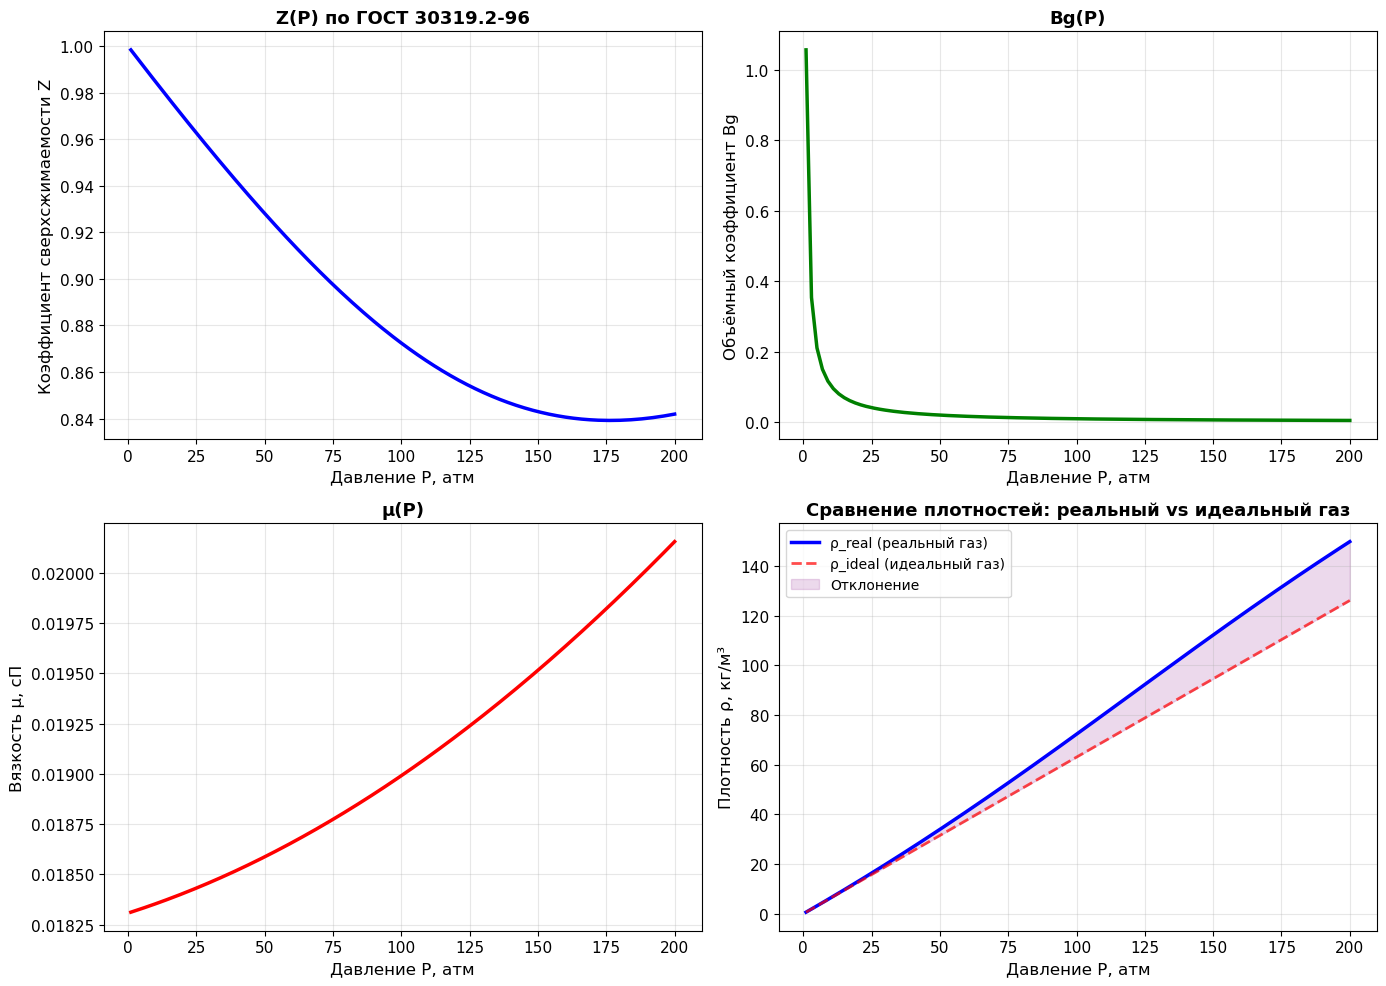

📊 PVT-характеристики при P = 100 атм, T = 310.0 К:
   Z  = 0.8724
   Bg = 0.0092
   μ  = 0.018991 сП


In [96]:
class Fluid:
    """PVT-модель газа по GERG-91 мод. (ГОСТ 30319.2-96)"""
    Pstd = 1  # атм
    Tstd = 293.15  # К
    R = 0.00831451  # МДж/(кмоль·К)

    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        self.xa = xa / 100
        self.xy = xy / 100
        self.M = 16.04  # Молярная масса метана, кг/кмоль

    def get_Z(self, P: float, T: float) -> float:
        P_mpa = P * 0.101325
        xa = self.xa
        xy = self.xy
        xz = 1 - xa - xy

        z_c = 1 - (0.0741 * self.rho_c - 0.006 - 0.063 * xa - 0.0575 * xy)**2
        M3 = (24.05525 * z_c * self.rho_c - 28.0135 * xa - 44.01 * xy) / xz
        H = 128.64 + 47.479 * M3

        B1 = (-0.425468 + 2.865e-3 * T - 4.62073e-6 * T**2 +
          (8.77118e-4 - 5.56281e-6 * T + 8.8151e-9 * T**2) * H +
          (-8.24747e-7 + 4.31436e-9 * T - 6.08319e-12 * T**2) * H**2)
        B2 = -0.1446 + 7.4091e-4 * T - 9.1195e-7 * T**2
        B23 = -0.339693 + 1.61176e-3 * T - 2.04429e-6 * T**2
        B3 = -0.86834 + 4.0376e-3 * T - 5.1657e-6 * T**2

        C1 = (-0.302488 + 1.95861e-3 * T - 3.16302e-6 * T**2 +
          (6.46422e-4 - 4.22876e-6 * T + 6.88157e-9 * T**2) * H +
          (-3.32805e-7 + 2.2316e-9 * T - 3.67713e-12 * T**2) * H**2)
        C2 = 7.8498e-3 - 3.9895e-5 * T + 6.1187e-8 * T**2
        C3 = 2.0513e-3 + 3.4888e-5 * T - 8.3703e-8 * T**2
        C223 = 5.52066e-3 - 1.68609e-5 * T + 1.57169e-8 * T**2
        C233 = 3.58783e-3 + 8.06674e-6 * T - 3.25798e-8 * T**2

        B_star = 0.72 + 1.875e-5 * (320 - T)**2
        C_star = 0.92 + 0.0013 * (T - 270)

        Bm = (xz**2 * B1 + xz * xa * B_star * (B1 + B2) - 
              1.73 * xz * xy * (B1 * B3)**0.5 + xa**2 * B2 + 
              2 * xa * xy * B23 + xy**2 * B3)
        Cm = (xz**3 * C1 +
              3 * xz**2 * xa * C_star * (C1**2 * C2)**(1/3) +
              2.76 * xz**2 * xy * (C1**2 * C3)**(1/3) +
              3 * xz * xa**2 * C_star * (C1 * C2**2)**(1/3) +
              6.6 * xz * xa * xy * (C1 * C2 * C3)**(1/3) +
              2.76 * xz * xy**2 * (C1 * C3**2)**(1/3) +
              xa**3 * C2 +
              3 * xa**2 * xy * C223 +
              3 * xa * xy**2 * C233 +
              xy**3 * C3)

        b = 1000 * P_mpa / (2.7715 * T)
        C0 = b**2 * Cm
        B0 = b * Bm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
        z = (1 + A2 + A1 / A2)/3
        return z

    def get_Bg(self, P: float, T: float) -> float:
        Z = self.get_Z(P, T)
        Bg = (self.Pstd * Z * T) / (P * self.Tstd)
        return Bg

# === ЗАГРУЗКА И ПОДГОТОВКА ИНТЕРПОЛЯТОРОВ ===
df = pd.read_csv('interp_data.csv', sep=';')

RHO_C = 0.6799
XA = 0.0651
XY = 0.9489
T_FIXED = 310.0

fluid = Fluid(rho_c=RHO_C, xa=XA, xy=XY)

# Обогащаем таблицу столбцами Z и Bg
col_pressure = [c for c in df.columns if 'pressure' in c.lower()][0]
col_viscosity = [c for c in df.columns if 'viscosity' in c.lower() or 'mu' in c.lower()][0]

if 'Z' not in df.columns and 'z' not in df.columns:
    df['Z'] = df[col_pressure].apply(lambda P: fluid.get_Z(P, T_FIXED))
if 'Bg' not in df.columns and 'bg' not in df.columns:
    df['Bg'] = df[col_pressure].apply(lambda P: fluid.get_Bg(P, T_FIXED))

col_Z = [c for c in df.columns if c.strip().lower() == 'z'][0]
col_Bg = [c for c in df.columns if c.strip().lower() == 'bg'][0]

x_data = df[col_pressure].values
interp_visc = LinearInterpolator(x_data, df[col_viscosity].values)
interp_Z = LinearInterpolator(x_data, df[col_Z].values)
interp_Bg = LinearInterpolator(x_data, df[col_Bg].values)

# === ПОСТРОЕНИЕ ГРАФИКОВ В СТАНДАРТНОМ ОФОРМЛЕНИИ ===
P_range = np.linspace(1, 200, 200)
Z_values = [interp_Z.predict(p) for p in P_range]
Bg_values = [interp_Bg.predict(p) for p in P_range]
mu_values = [interp_visc.predict(p) for p in P_range]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(P_range, Z_values, 'b-', linewidth=2.5)
axes[0, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 0].set_ylabel('Коэффициент сверхсжимаемости Z', fontsize=12)
axes[0, 0].set_title('Z(P) по ГОСТ 30319.2-96', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(P_range, Bg_values, 'g-', linewidth=2.5)
axes[0, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 1].set_ylabel('Объёмный коэффициент Bg', fontsize=12)
axes[0, 1].set_title('Bg(P)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(P_range, mu_values, 'r-', linewidth=2.5)
axes[1, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 0].set_ylabel('Вязкость μ, сП', fontsize=12)
axes[1, 0].set_title('μ(P)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Расчет плотностей для графика сравнения
R_gas = 8.314
M_gas = 0.01604
rho_ideal = [(p * 101325 * M_gas) / (R_gas * T_FIXED) for p in P_range]
rho_real = [rho_ideal[i] / Z_values[i] for i in range(len(P_range))]

axes[1, 1].plot(P_range, rho_real, 'b-', linewidth=2.5, label='ρ_real (реальный газ)')
axes[1, 1].plot(P_range, rho_ideal, 'r--', linewidth=2, alpha=0.7, label='ρ_ideal (идеальный газ)')
axes[1, 1].fill_between(P_range, rho_real, rho_ideal, alpha=0.15, color='purple', label='Отклонение')
axes[1, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 1].set_ylabel('Плотность ρ, кг/м³', fontsize=12)
axes[1, 1].set_title('Сравнение плотностей: реальный vs идеальный газ', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 PVT-характеристики при P = 100 атм, T = {T_FIXED} К:")
print(f"   Z  = {interp_Z.predict(100):.4f}")
print(f"   Bg = {interp_Bg.predict(100):.4f}")
print(f"   μ  = {interp_visc.predict(100):.6f} сП")

## 2. МОДЕЛЬ ПЛАСТА — КРИВАЯ IPR

Коэффициент продуктивности при P_res = 100.0 атм:
μ(100.0 атм) = 0.018991 сП
Формула: C = (β·k·h) / (μ·ln(re/rw))
= (0.00852702·50.0·25.0) / (0.018991·ln(500.0/0.1))
C = 65.8964 ст.м³/(сут·атм)


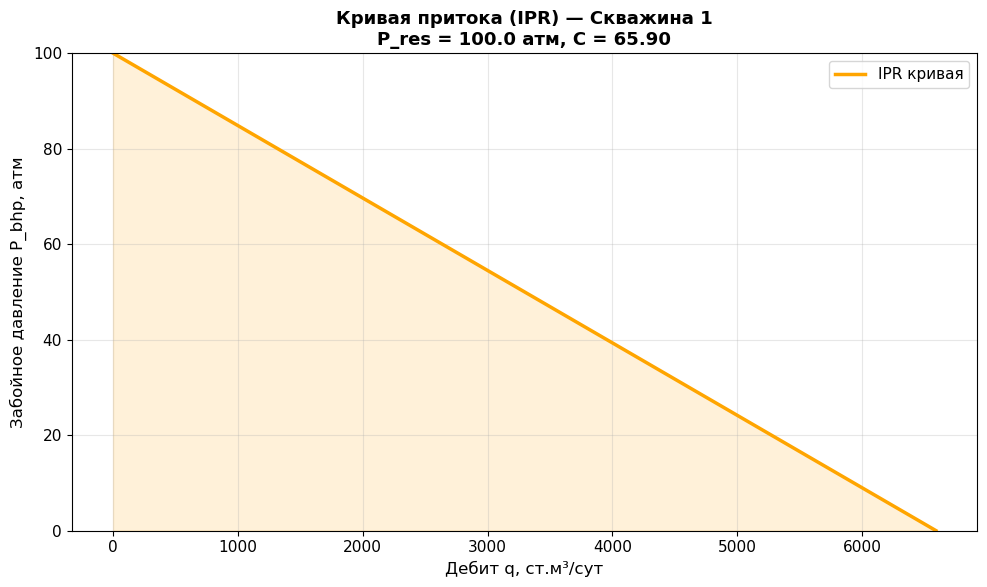

In [97]:
k = 50.0
h = 25.0
re = 500.0
rw = 0.1
P_res = 100.0
T = 310.0

beta = 0.00852702
mu_cP = interp_visc.predict(P_res)

C_prod = (beta * k * h) / (mu_cP * math.log(re / rw))

print(f"Коэффициент продуктивности при P_res = {P_res} атм:")
print(f"μ({P_res} атм) = {mu_cP:.6f} сП")
print(f"Формула: C = (β·k·h) / (μ·ln(re/rw))")
print(f"= ({beta}·{k}·{h}) / ({mu_cP:.6f}·ln({re}/{rw}))")
print(f"C = {C_prod:.4f} ст.м³/(сут·атм)")

def well_q_linear(P_res, P_bhp, C):
    if P_bhp >= P_res:
        return 0.0
    return max(0, C * (P_res - P_bhp))

# Диапазон забойных давлений от 100 до 0 атм
P_bhp_range = np.linspace(100, 0, 100)
q_ipr = [well_q_linear(P_res, p, C_prod) for p in P_bhp_range]

plt.figure(figsize=(10, 6))
plt.plot(q_ipr, P_bhp_range, color='orange', linewidth=2.5, label='IPR кривая')
plt.fill_between(q_ipr, P_bhp_range, alpha=0.15, color='orange')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=12)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=12)
plt.title(f'Кривая притока (IPR) — Скважина 1\nP_res = {P_res} атм, C = {C_prod:.2f}', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.ylim(0, 100)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()